# Example notebook: plot aerial imagery from Rotterdam Hub

In [26]:
from pprint import pprint
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

## Access data

In [30]:
# optionally print information about all datasets
# response = requests.get('https://hub.clearly.app/api/datasets?query={"ownerHubId":"65e9c5c8fe2ac522c6ac7b43"}')
# response.raise_for_status()
# content = response.json()
# pprint(content)

response = requests.get("https://hub.clearly.app/api/datasets/65ef1e39fe2ac522c6ac7b5e")
response.raise_for_status()
content = response.json()
# optionally print information about dataset
# pprint(content)
WMS_URL = content['resources'][0]['url']


## Plot sample image

Status: 200
Content-Type: image/png


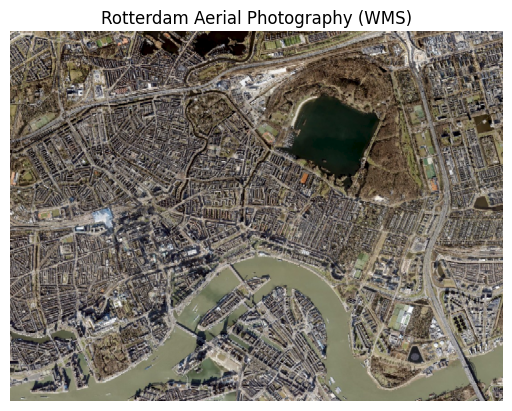

In [31]:
# Define a bounding box around Rotterdam (EPSG:4326, lon/lat order for WMS 1.1.1)
bbox = "4.45,51.90,4.55,51.95"

params = {
    "service": "WMS",
    "request": "GetMap",
    "version": "1.1.1",
    "layers": "0",
    "styles": "",
    "srs": "EPSG:4326",
    "bbox": bbox,
    "width": 800,
    "height": 600,
    "format": "image/png",
    "transparent": "true",
}

# Request the image
response = requests.get(WMS_URL, params=params, timeout=30)
response.raise_for_status()

content_type = response.headers.get("Content-Type", "")
print("Status:", response.status_code)
print("Content-Type:", content_type)

if "image" not in content_type.lower():
    preview = response.text[:500]
    raise ValueError(f"WMS did not return an image. Response preview:\n{preview}")

# Load image into PIL
image = Image.open(BytesIO(response.content))

# Display
plt.imshow(image)
plt.axis("off")
plt.title("Rotterdam Aerial Photography (WMS)")
plt.show()